In [38]:
# importing required libs and reading the dataset

# base required libs
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

import pandas as pd

# testing required libs
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

df = pd.read_csv('../dataset/store_location_dataset.csv')

In [39]:
# specifying the features and target (X and y) - splitting data into train and test with 80% train and 20% test size
# note that for this specific model we are using stratify = y to denote the fact that our targets (good and bad) are widely spreaded

features = ['dist_metro', 'num_residential', 'avg_income', 'traffic', 'rent_per_sqm', 'has_parking', 'competition_count']

X = df[features]
y = df['suitable'].map({'good' : 1, 'bad' : 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [40]:
# furthermore specifying the numerical and categorical features for making the preprocessor and scaling our data

numerical_features = ['dist_metro', 'num_residential', 'avg_income', 'rent_per_sqm', 'competition_count']
categorical_features = ['traffic', 'has_parking']

preprocessor = ColumnTransformer([
    ('numerical', StandardScaler(), numerical_features),
    ('categorical', OneHotEncoder(drop = 'first'), categorical_features)
])

In [41]:
# defining the model/pipeline and making the fit

model = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression())
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [42]:
# making prediction

y_pred = model.predict(X_test)

📊 ارزیابی مدل رگرسیون لجستیک

✅ Accuracy (دقت کل): 0.9000

📌 Confusion Matrix (ماتریس درهم‌ریختگی):
        Predicted bad  Predicted good
Actual bad          50              11
Actual good          5              94

📋 Classification Report:
              precision    recall  f1-score   support

         bad       0.91      0.82      0.86        61
        good       0.90      0.95      0.92        99

    accuracy                           0.90       160
   macro avg       0.90      0.88      0.89       160
weighted avg       0.90      0.90      0.90       160

🎯 ROC AUC: 0.9531

🔁 Cross-Validation ROC AUC (5-fold):
   میانگین: 0.9485
   انحراف معیار: 0.0119

🧱 Baseline (همیشه اکثریت): Accuracy = 0.6188, ROC AUC = 0.5000
   ➜ مدل ما 0.2812 دقت بالاتر دارد.

📈 ضرایب مدل (اهمیت و جهت تأثیر):
          Feature  Coefficient
  has_parking_yes     3.190118
       dist_metro    -2.306448
  num_residential     1.563251
      traffic_low    -1.232296
       avg_income     1.101299
   traffic_m

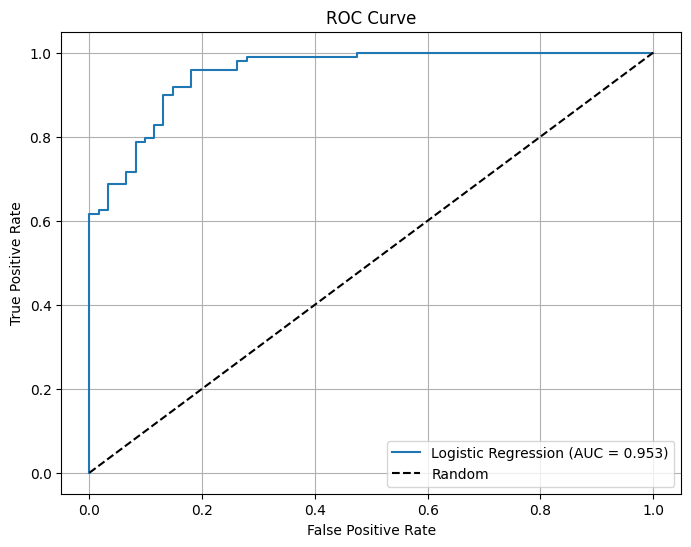


✅ تحلیل به پایان رسید.


In [43]:
# testing the model with certain techniques in order to see if the model is working fine or not and gaining stats (AI generated)

y_prob = model.predict_proba(X_test)[:, 1]

# ---------- معیارهای اصلی ----------
print("=" * 60)
print("📊 ارزیابی مدل رگرسیون لجستیک")
print("=" * 60)

acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy (دقت کل): {acc:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\n📌 Confusion Matrix (ماتریس درهم‌ریختگی):")
print(f"        Predicted bad  Predicted good")
print(f"Actual bad      {cm[0,0]:>6}          {cm[0,1]:>6}")
print(f"Actual good     {cm[1,0]:>6}          {cm[1,1]:>6}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['bad', 'good']))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"🎯 ROC AUC: {roc_auc:.4f}")

# ---------- اعتبارسنجی متقابل ----------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
print(f"\n🔁 Cross-Validation ROC AUC (5-fold):")
print(f"   میانگین: {cv_scores.mean():.4f}")
print(f"   انحراف معیار: {cv_scores.std():.4f}")

# ---------- مقایسه با مدل پایه ----------
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_dummy_pred = dummy.predict(X_test)
y_dummy_prob = dummy.predict_proba(X_test)[:, 1]
dummy_acc = accuracy_score(y_test, y_dummy_pred)
dummy_auc = roc_auc_score(y_test, y_dummy_prob)
print(f"\n🧱 Baseline (همیشه اکثریت): Accuracy = {dummy_acc:.4f}, ROC AUC = {dummy_auc:.4f}")
print(f"   ➜ مدل ما {acc - dummy_acc:.4f} دقت بالاتر دارد.")

# ---------- ضرایب مدل ----------
enc = model.named_steps['preprocess'].named_transformers_['categorical']
cat_names = enc.get_feature_names_out(categorical_features)
all_features = numerical_features + list(cat_names)
coef = model.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({'Feature': all_features, 'Coefficient': coef})
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs', ascending=False)

print("\n📈 ضرایب مدل (اهمیت و جهت تأثیر):")
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))

print("\n   🧠 تحلیل سریع:")
for _, row in coef_df.iterrows():
    direction = "➕ مثبت (مناسب)" if row['Coefficient'] > 0 else "➖ منفی (نامناسب)"
    print(f"      {row['Feature']:30s}: {row['Coefficient']:8.4f}  {direction}")

# ---------- نمودار ROC ----------
plt.figure(figsize=(8,6))
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

print("\n✅ تحلیل به پایان رسید.")